In [1]:
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
import numpy as np
import pandas as pd
import math
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
import time

def set_precision(dtype_str='float32'):
    dtype_map = {
        'float16': torch.float16,
        'bfloat16': torch.bfloat16,
        'float32': torch.float32,
        'tf32': torch.float32,
        'float64': torch.float64,
    }
    dtype = dtype_map.get(dtype_str, torch.float32)
    torch.set_default_dtype(dtype)
    if dtype_str == 'tf32' and torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    else:
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
    return dtype

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
class PINN(nn.Module):
    def __init__(self, dims, dtype=torch.float32):
        super(PINN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(dims) - 1):
            self.layers.append(nn.Linear(dims[i], dims[i + 1], dtype=dtype))
            if i < len(dims) - 2:
                self.layers.append(nn.Tanh())
        self.dtype = dtype

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [3]:
def calculate_burgers(u, xt, nu=0.01/np.pi):
    grads = torch.autograd.grad(outputs=u, inputs=xt, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]
    grads_xx = torch.autograd.grad(outputs=u_x, inputs=xt, grad_outputs=torch.ones_like(u_x), create_graph=True, retain_graph=True)[0]
    u_xx = grads_xx[:, 0:1]
    return u_t + u * u_x - nu * u_xx

def normalize_inputs(x, t, x_range=(-1, 1), t_range=(0, 1)):
    x_norm = 2 * (x - x_range[0]) / (x_range[1] - x_range[0]) - 1
    t_norm = 2 * (t - t_range[0]) / (t_range[1] - t_range[0]) - 1
    return x_norm, t_norm

def compute_loss(model, x_bc, t_bc, u_bc, x_col, t_col, nu=0.01/np.pi):
    x_bc_t = torch.tensor(np.hstack([x_bc, t_bc]), requires_grad=True, dtype=model.dtype)
    u_bc_t = torch.tensor(u_bc, dtype=model.dtype)
    u_pred_bc = model(x_bc_t)
    loss_bc = torch.mean((u_pred_bc - u_bc_t) ** 2)
    x_norm, t_norm = normalize_inputs(x_col, t_col)
    x_col_t = torch.tensor(np.hstack([x_norm, t_norm]), requires_grad=True, dtype=model.dtype)
    x_col_t.requires_grad_(True)
    u_pred_col = model(x_col_t)
    residual = calculate_burgers(u_pred_col, x_col_t, nu)
    loss_pde = torch.mean(residual ** 2)
    return loss_bc + loss_pde, loss_bc, loss_pde

def generate_burgers_data(N_bc=100, N_col=2000, dtype=np.float32):
    x_bc = np.linspace(-1, 1, N_bc).reshape(-1, 1).astype(dtype)
    t_bc = np.zeros((N_bc, 1), dtype=dtype)
    u_bc = -np.sin(np.pi * x_bc).astype(dtype)
    x_col = np.random.uniform(-1, 1, (N_col, 1)).astype(dtype)
    t_col = np.random.uniform(0, 0.99, (N_col, 1)).astype(dtype)
    return x_bc, t_bc, u_bc, x_col, t_col

In [4]:
from matplotlib.colors import LogNorm

def plot_loss_landscape(model, x_bc, t_bc, u_bc, x_col, t_col, weight_idx1=0, weight_idx2=1, range_val=0.1, resolution=50, vmin=None, vmax=None, dtype=torch.float32, prec='float32'):
    if prec == 'float64':
        x_bc, t_bc, u_bc, x_col, t_col = x_bc.astype(np.float64), t_bc.astype(np.float64), u_bc.astype(np.float64), x_col.astype(np.float64), t_col.astype(np.float64)
    
    w1 = model.layers[0].weight.data.flatten()[weight_idx1].item()
    w2 = model.layers[0].weight.data.flatten()[weight_idx2].item()
    w1_vals = np.linspace(w1 - range_val, w1 + range_val, resolution)
    w2_vals = np.linspace(w2 - range_val, w2 + range_val, resolution)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    losses = np.zeros_like(W1)
    original_weights = [p.data.clone() for p in model.parameters()]
    
    for i in range(resolution):
        for j in range(resolution):
            with torch.no_grad():
                model.layers[0].weight.data.flatten()[weight_idx1] = torch.tensor(W1[i, j], dtype=dtype)
                model.layers[0].weight.data.flatten()[weight_idx2] = torch.tensor(W2[i, j], dtype=dtype)
            loss, _, _ = compute_loss(model, x_bc, t_bc, u_bc, x_col, t_col)
            losses[i, j] = loss.item()
    
    for p, orig in zip(model.parameters(), original_weights):
        p.data.copy_(orig)

    norm = LogNorm(vmin=max(vmin, 1e-10), vmax=vmax)
    
    fig = plt.figure(figsize=(12, 5))
    
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(W1, W2, losses, cmap=cm.viridis, norm=norm, alpha=0.9)
    ax1.set_xlabel(f'Weight {weight_idx1}')
    ax1.set_ylabel(f'Weight {weight_idx2}')
    ax1.set_zlabel('Loss')
    ax1.set_title(f'3D Loss Landscape ({prec})')
    fig.colorbar(surf, ax=ax1, shrink=0.5, label='Loss (log scale)')

    ax2 = fig.add_subplot(122)
    contour = ax2.contourf(W1, W2, losses, levels=20, cmap=cm.viridis, norm=norm)
    ax2.plot(w1, w2, 'r*', markersize=15, label='Current weights')
    ax2.set_xlabel(f'Weight {weight_idx1}')
    ax2.set_ylabel(f'Weight {weight_idx2}')
    ax2.set_title('Loss Contours')
    ax2.legend()
    fig.colorbar(contour, ax=ax2, label='Loss (log scale)')
    
    plt.tight_layout()
    plt.savefig(f'loss_landscape_burgers_small_1e-2_{prec}.png', dpi=150)
    plt.show()
    
    return W1, W2, losses

In [5]:
def train_pinn(x_bc, t_bc, u_bc, x_col, t_col, precision='float32', epochs_adam=3000, epochs_lbfgs=1000, weight_idx1=0, weight_idx2=1, range_val=0.1, resolution=50):
    dtype = set_precision(precision)
    if precision == 'float64':
        x_bc, t_bc, u_bc, x_col, t_col = x_bc.astype(np.float64), t_bc.astype(np.float64), u_bc.astype(np.float64), x_col.astype(np.float64), t_col.astype(np.float64)

    dims = [2, 30, 30, 30, 30, 30, 30, 30, 30, 1]
    model = PINN(dims, dtype=dtype)
    
    history = {'loss': [], 'loss_bc': [], 'loss_pde': [], 'time': []}

    print(f"Начало обучения {dtype}")
    start_time = time.time()

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epochs_adam):
        optimizer.zero_grad()
        loss, _, _ = compute_loss(model, x_bc, t_bc, u_bc, x_col, t_col)
        loss.backward()
        optimizer.step()
        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Loss={loss.item()}")

    lbfgs = torch.optim.LBFGS(model.parameters(), line_search_fn='strong_wolfe')

    def closure():
        lbfgs.zero_grad()
        loss, _, _ = compute_loss(model, x_bc, t_bc, u_bc, x_col, t_col)
        loss.backward()
        return loss
    
    for epoch in range(epochs_lbfgs):
        lbfgs.step(closure)
        if epoch % 200 == 0:
            loss, loss_bc, loss_pde = compute_loss(model, x_bc, t_bc, u_bc, x_col, t_col)
            history['loss'].append(loss.item())
            history['loss_bc'].append(loss_bc.item())
            history['loss_pde'].append(loss_pde.item())
            history['time'].append(time.time() - start_time)
            print(f"Epoch {epoch} | Loss: {loss.item()} | BC: {loss_bc.item()} | PDE: {loss_pde.item()}")
    
    total_time = time.time() - start_time
    print(f"Обучение {dtype} завершено за {total_time} секунд")

    vmin, vmax = 1.0, 0.0
    w1 = model.layers[0].weight.data.flatten()[weight_idx1].item()
    w2 = model.layers[0].weight.data.flatten()[weight_idx2].item()
    w1_vals = np.linspace(w1 - range_val, w1 + range_val, resolution)
    w2_vals = np.linspace(w2 - range_val, w2 + range_val, resolution)
    W1, W2 = np.meshgrid(w1_vals, w2_vals)
    losses = np.zeros_like(W1)
    original_weights = [p.data.clone() for p in model.parameters()]
    
    for i in range(resolution):
        for j in range(resolution):
            with torch.no_grad():
                model.layers[0].weight.data.flatten()[weight_idx1] = torch.tensor(W1[i, j], dtype=dtype)
                model.layers[0].weight.data.flatten()[weight_idx2] = torch.tensor(W2[i, j], dtype=dtype)
            loss, _, _ = compute_loss(model, x_bc, t_bc, u_bc, x_col, t_col)
            vmin = min(vmin, loss.item() * 0.9)
            vmax = max(vmax, loss.item() * 1.1)
    
    for p, orig in zip(model.parameters(), original_weights):
        p.data.copy_(orig)
    
    return model, history, total_time, vmin, vmax

Начало обучения torch.float32
Epoch 0: Loss=0.49310556054115295
Epoch 500: Loss=0.1359221488237381
Epoch 1000: Loss=0.10841000080108643
Epoch 1500: Loss=0.0769561156630516
Epoch 2000: Loss=0.0586971789598465
Epoch 2500: Loss=0.019783899188041687
Epoch 3000: Loss=0.014203638769686222
Epoch 3500: Loss=0.011035647243261337
Epoch 4000: Loss=0.009270813316106796
Epoch 4500: Loss=0.008029242046177387
Epoch 0 | Loss: 0.006830275058746338 | BC: 0.0029868700075894594 | PDE: 0.003843405283987522
Epoch 200 | Loss: 1.4236889910534956e-05 | BC: 2.6944358069158625e-06 | PDE: 1.1542454558366444e-05
Epoch 400 | Loss: 9.770506949280389e-06 | BC: 1.6762601262598764e-06 | PDE: 8.094246368273161e-06
Epoch 600 | Loss: 9.770506949280389e-06 | BC: 1.6762601262598764e-06 | PDE: 8.094246368273161e-06
Epoch 800 | Loss: 9.770506949280389e-06 | BC: 1.6762601262598764e-06 | PDE: 8.094246368273161e-06
Epoch 1000 | Loss: 9.770506949280389e-06 | BC: 1.6762601262598764e-06 | PDE: 8.094246368273161e-06
Epoch 1200 | Los

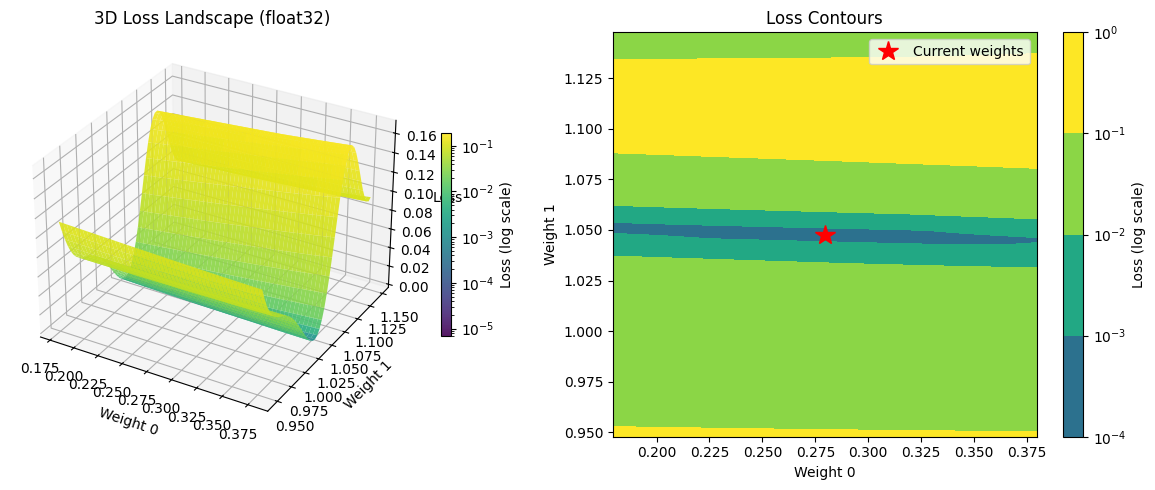

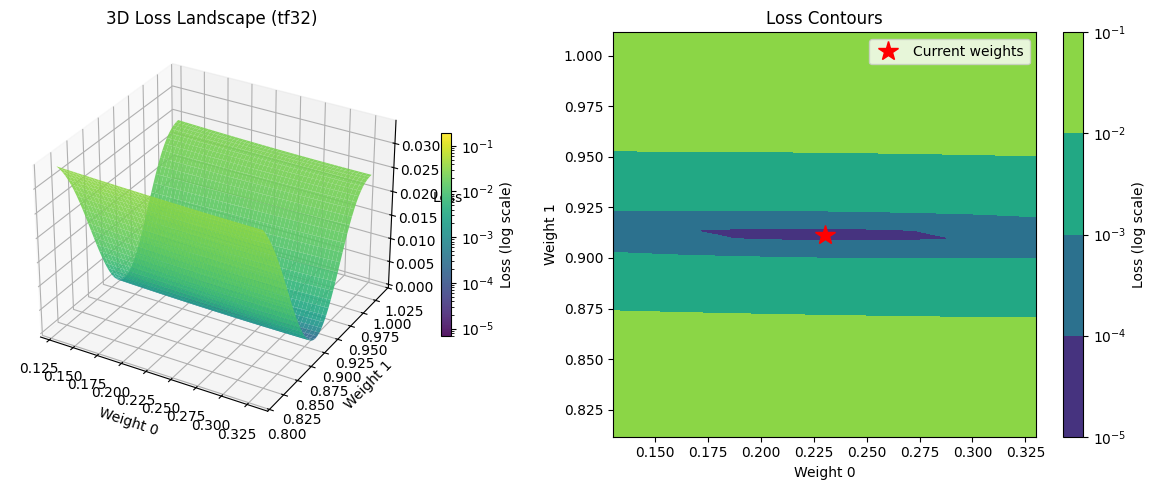

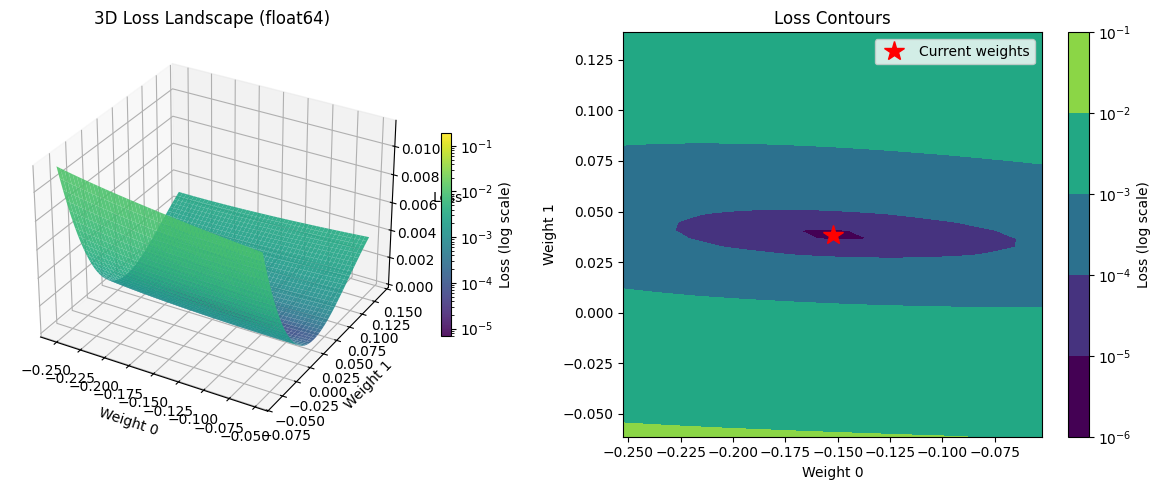

In [6]:
precisions = ['float32', 'tf32', 'float64']
results = {}
vmin, vmax = 1.0, 0.0
x_bc, t_bc, u_bc, x_col, t_col = generate_burgers_data(dtype=np.float32)
for prec in precisions:
    model, history, train_time, mn, mx = train_pinn(x_bc, t_bc, u_bc, x_col, t_col, precision=prec, epochs_adam=5000, epochs_lbfgs=2000)
    results[prec] = {
        'model': model,
        'history': history,
        'time': train_time,
        'final_loss': history['loss'][-1]
    }
    print(f"{prec}, time: {time}, loss{history['loss'][-1]}")
    vmin = min(vmin, mn)
    vmax = max(vmax, mx)

for prec in precisions:
    dtype = set_precision(prec)
    plot_loss_landscape(results[prec]['model'], x_bc, t_bc, u_bc, x_col, t_col, vmin=vmin, vmax=vmax, dtype=dtype, prec=prec)